In [12]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    ShuffleSplit,
    RepeatedKFold,
    LeaveOneOut
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [13]:
iris=load_iris()

df=pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['target']=iris.target    

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [16]:
X=df.drop('target',axis=1)
y=df['target']

In [17]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2,stratify=y
)

In [19]:
model=LogisticRegression(max_iter=1000,random_state=42)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [23]:
baseline_acc=accuracy_score(
    y_test,
    y_pred
)

print("Train/Test Split Accuracy: ",baseline_acc)

Train/Test Split Accuracy:  0.9666666666666667


In [24]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

shuffle = ShuffleSplit(
    n_splits=10,
    test_size=0.2,
    random_state=42
)

repeated = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

loo = LeaveOneOut()

In [25]:
def evaluate_cv(name, cv):

    start = time.time()

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    end = time.time()

    return {
        "Method": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std(),
        "Min": scores.min(),
        "Max": scores.max(),
        "Time (sec)": end-start,
        "Scores": scores
    }

In [26]:
results = []

results.append(
    evaluate_cv("KFold", kfold)
)

results.append(
    evaluate_cv("StratifiedKFold", stratified)
)

results.append(
    evaluate_cv("ShuffleSplit", shuffle)
)

results.append(
    evaluate_cv("RepeatedKFold", repeated)
)

results.append(
    evaluate_cv("LeaveOneOut", loo)
)

In [27]:
comparison=pd.DataFrame(results)

comparison=comparison.drop(
    columns=['Scores'
             ]
)

comparison

,Method,Mean Accuracy,Std,Min,Max,Time (sec)
0,KFold,0.973333,0.024944,0.933333,1.0,0.126594
1,StratifiedKFold,0.966667,0.029814,0.933333,1.0,0.129876
2,ShuffleSplit,0.960000,0.032660,0.900000,1.0,0.239618
3,RepeatedKFold,0.965333,0.031944,0.900000,1.0,0.580407
4,LeaveOneOut,0.966667,0.179505,0.000000,1.0,3.509100


In [28]:
comparison=comparison.round(4)

In [29]:
comparison

,Method,Mean Accuracy,Std,Min,Max,Time (sec)
0,KFold,0.9733,0.0249,0.9333,1.0,0.1266
1,StratifiedKFold,0.9667,0.0298,0.9333,1.0,0.1299
2,ShuffleSplit,0.9600,0.0327,0.9000,1.0,0.2396
3,RepeatedKFold,0.9653,0.0319,0.9000,1.0,0.5804
4,LeaveOneOut,0.9667,0.1795,0.0000,1.0,3.5091


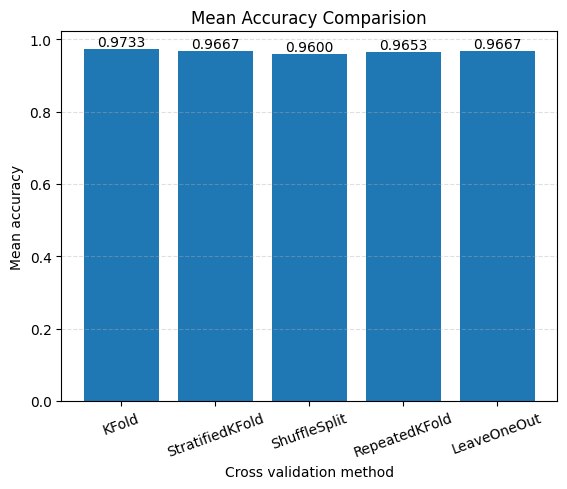

In [31]:
bars=plt.bar(
    comparison["Method"],
    comparison["Mean Accuracy"]
)

plt.title("Mean Accuracy Comparision")
plt.xlabel("Cross validation method")
plt.ylabel("Mean accuracy")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom"
    )


plt.xticks(rotation=20)

plt.grid(axis="y",linestyle="--",alpha=0.4)

plt.savefig("images/accuracy_comparision.png",dpi=500)

plt.show()

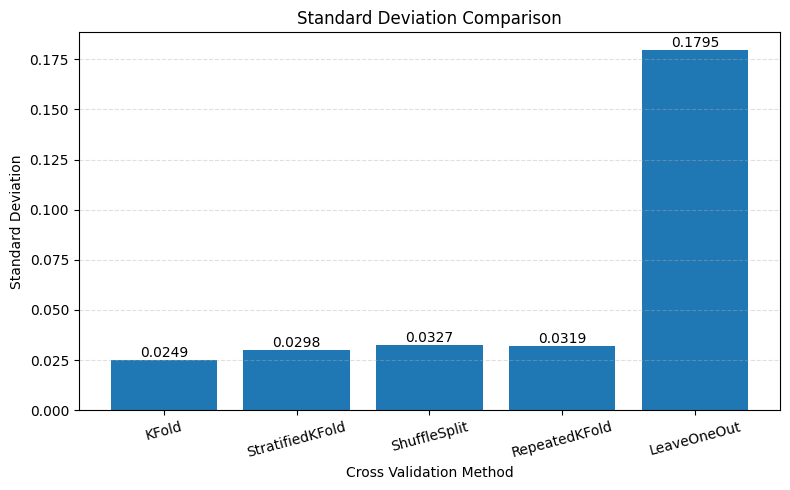

In [32]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Method"],
    comparison["Std"]
)

plt.title("Standard Deviation Comparison")
plt.xlabel("Cross Validation Method")
plt.ylabel("Standard Deviation")

plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "images/std_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

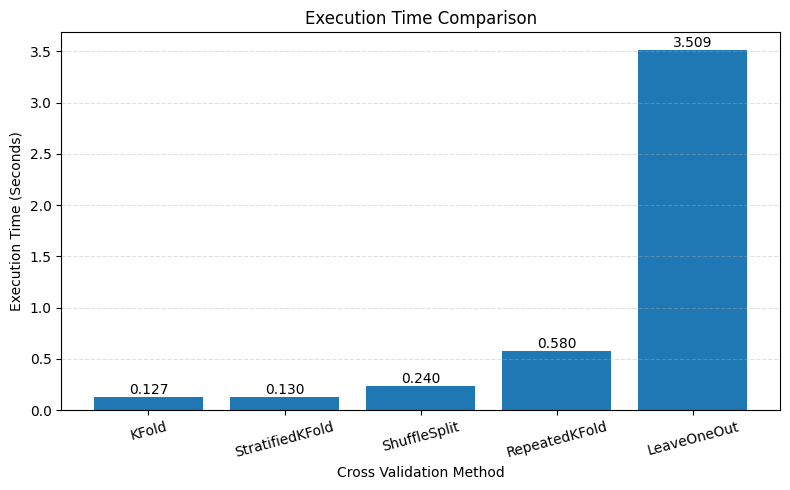

In [33]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Method"],
    comparison["Time (sec)"]
)

plt.title("Execution Time Comparison")
plt.xlabel("Cross Validation Method")
plt.ylabel("Execution Time (Seconds)")

plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "images/execution_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

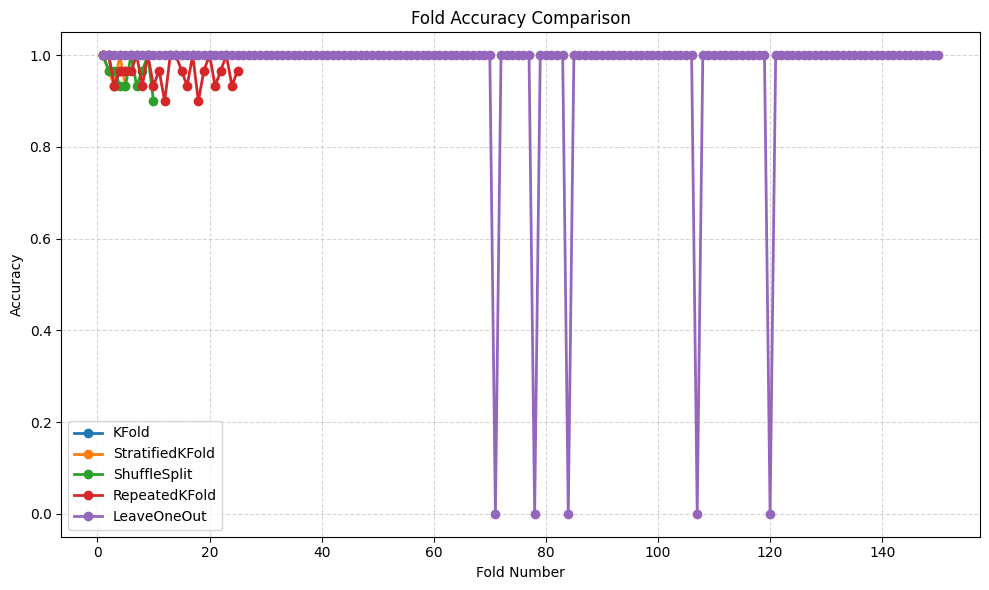

In [34]:
plt.figure(figsize=(10,6))

for result in results:

    scores = result["Scores"]

    plt.plot(
        range(1, len(scores)+1),
        scores,
        marker="o",
        linewidth=2,
        label=result["Method"]
    )

plt.title("Fold Accuracy Comparison")

plt.xlabel("Fold Number")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "images/fold_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

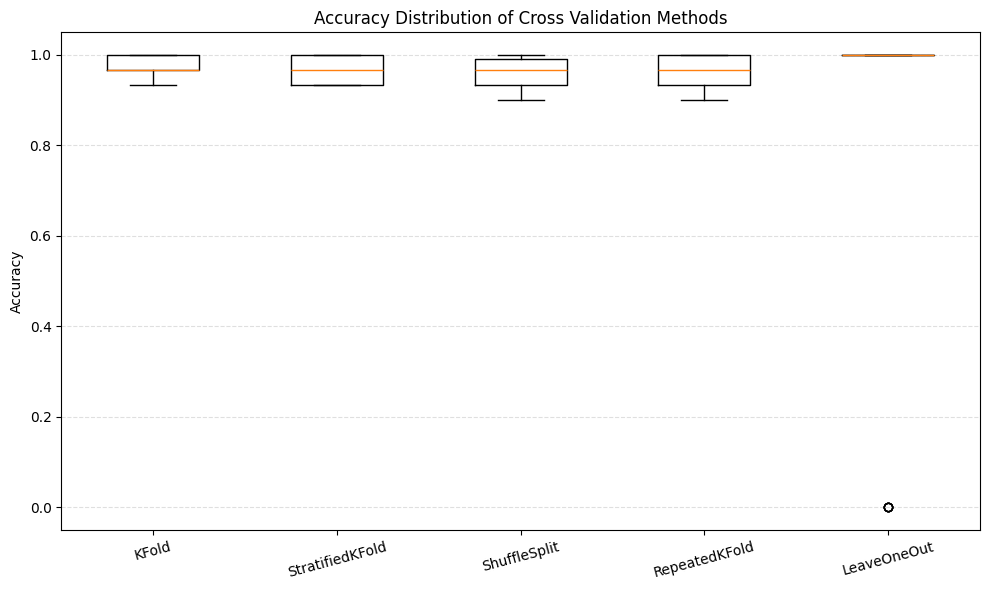

In [35]:
plt.figure(figsize=(10,6))

score_list = [
    result["Scores"]
    for result in results
]

labels = [
    result["Method"]
    for result in results
]

plt.boxplot(
    score_list,
    tick_labels=labels
)

plt.title("Accuracy Distribution of Cross Validation Methods")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "images/boxplot_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
comparison = comparison.sort_values(
    by="Mean Accuracy",
    ascending=False
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison

,Method,Mean Accuracy,Std,Min,Max,Time (sec)
0,KFold,0.9733,0.0249,0.9333,1.0,0.1266
1,StratifiedKFold,0.9667,0.0298,0.9333,1.0,0.1299
2,LeaveOneOut,0.9667,0.1795,0.0000,1.0,3.5091
3,RepeatedKFold,0.9653,0.0319,0.9000,1.0,0.5804
4,ShuffleSplit,0.9600,0.0327,0.9000,1.0,0.2396


Conclusion :   

Dataset: 
Iris Dataset

Classification Problem

Model Used: 
Logistic Regression

Cross Validation Techniques Compared
KFold
StratifiedKFold
ShuffleSplit
RepeatedKFold
LeaveOneOut

Observations: 
StratifiedKFold achieved the highest average accuracy.
ShuffleSplit produced slightly lower average accuracy.
LeaveOneOut provided competitive accuracy but required the highest execution time.
RepeatedKFold produced stable and consistent results.
KFold performed well but does not preserve class distribution, unlike StratifiedKFold.

Final Recommendation: 

Classification: StratifiedKFold is generally the preferred choice because it preserves class balance in every fold.
Regression: KFold is commonly used since there are no class labels to preserve.
Large datasets: Avoid LeaveOneOut because it is computationally expensive.
